In [1]:
import os

# This notebook is for loading tiffs changing the resolution and then resaving them

In [2]:
# example tif path = ...\SDS_performance_analysis\data\sat_images\<sitename>\<satname>\<tiff_fn>.tif
# sitename e.g. = californiatorreypines 
# satname e.g. = L5, PS, S2 other landsat missions etc.
tiff_dir = os.path.join(os.path.dirname(os.getcwd()), 'SDS_performance_analysis', 'data', 'sat_images')
print(tiff_dir)

c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images


In [3]:
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

from change_tiff_res import resample_tiff

In [4]:
# Find TIFFs recursively and keep the first five for a quick visual test.
tiff_files = sorted(glob(os.path.join(tiff_dir, '**', '*.tif'), recursive=True))
if len(tiff_files) < 5:
    tiff_files.extend(sorted(glob(os.path.join(tiff_dir, '**', '*.tiff'), recursive=True)))

tiff_files = sorted(set(tiff_files))[:5]
print(f'Found {len(tiff_files)} TIFF files for testing.')
for fp in tiff_files:
    print(fp)

Found 5 TIFF files for testing.
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19870522_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19870911_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19870927_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19880218_089083.tif
c:\Users\jnicolow\Documents\research\CRC\SDS_performance_analysis\data\sat_images\australianarrabeen\L5\L5_19880609_089083.tif


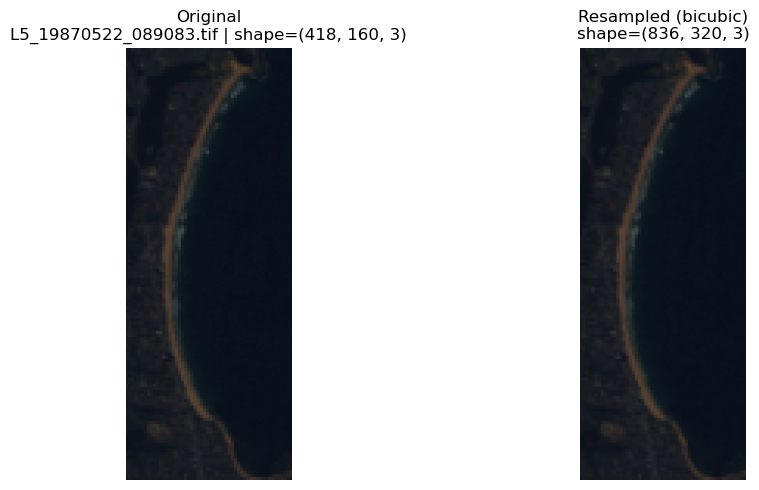

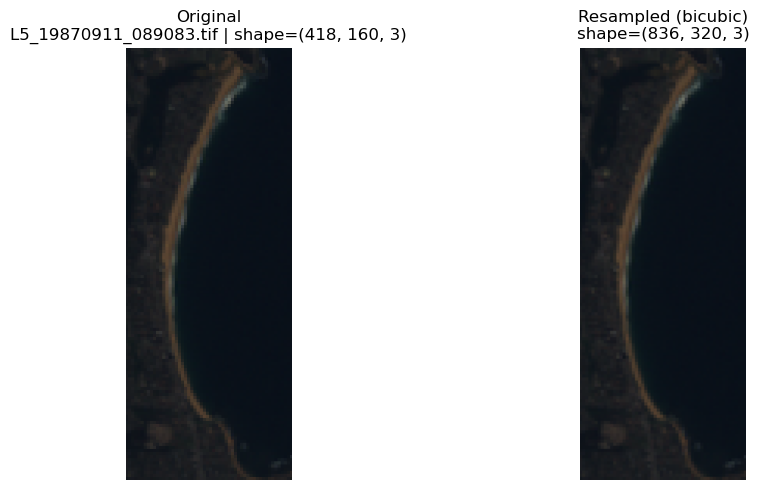

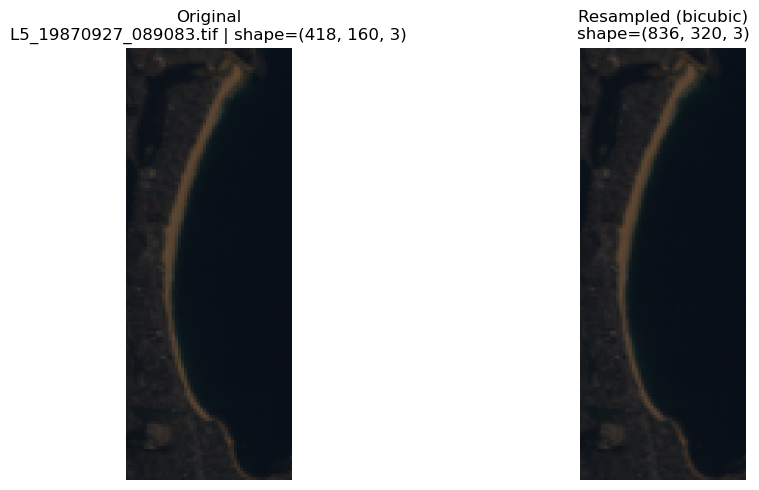

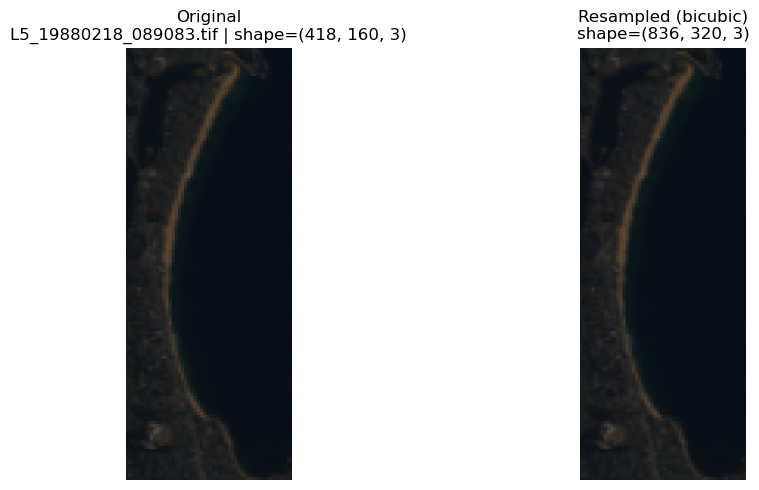

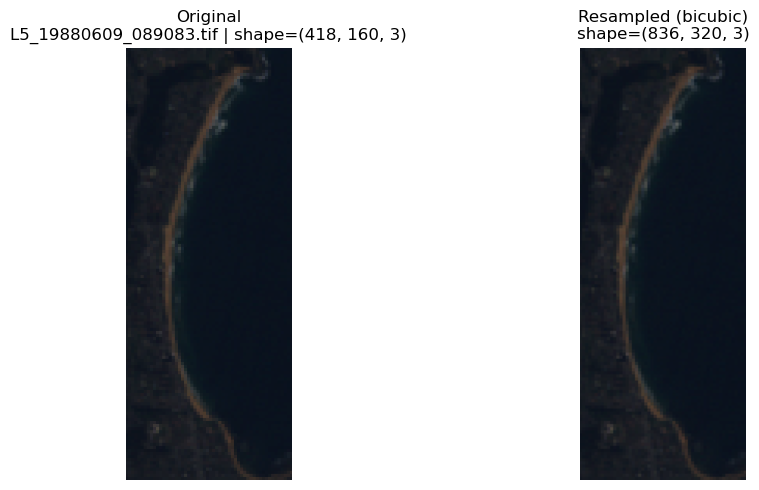

In [8]:
# Plot original vs resampled (no file writing in this test).
# For multi-band rasters, visualize RGB only (bands 0, 1, 2).
technique = 'bicubic'  # change to 'bilinear' to compare
upsample_scale = 2


def to_display_array(arr: np.ndarray) -> np.ndarray:
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        if arr.shape[2] >= 3:
            return arr[:, :, :3]
        return arr[:, :, 0]
    raise ValueError(f'Unexpected array shape for plotting: {arr.shape}')


for fp in tiff_files:
    with rasterio.open(fp) as src:
        original = src.read()  # (bands, h, w)
        height, width = src.height, src.width

    if original.shape[0] == 1:
        original_array = original[0]
    else:
        original_array = np.transpose(original, (1, 2, 0))

    desired_resolution = (height * upsample_scale, width * upsample_scale)
    upsampled_array = resample_tiff(
        tiff_path=fp,
        desired_resolution=desired_resolution,
        technique=technique,
        save_path=None,  # explicitly do not save for this test
    )

    original_display = to_display_array(original_array)
    upsampled_display = to_display_array(upsampled_array)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(original_display, cmap='gray' if original_display.ndim == 2 else None)
    axes[0].set_title(f'Original\n{Path(fp).name} | shape={original_display.shape}')
    axes[0].axis('off')

    axes[1].imshow(upsampled_display, cmap='gray' if upsampled_display.ndim == 2 else None)
    axes[1].set_title(f'Resampled ({technique})\nshape={upsampled_display.shape}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

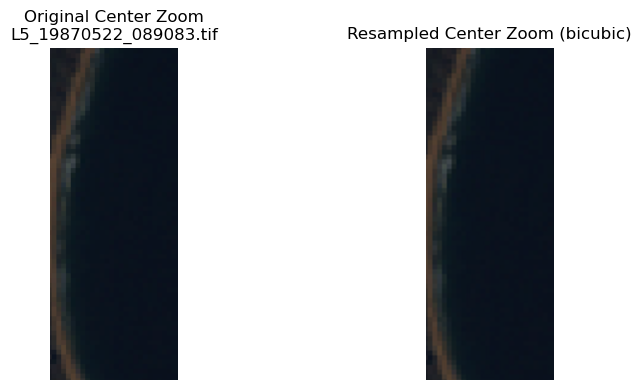

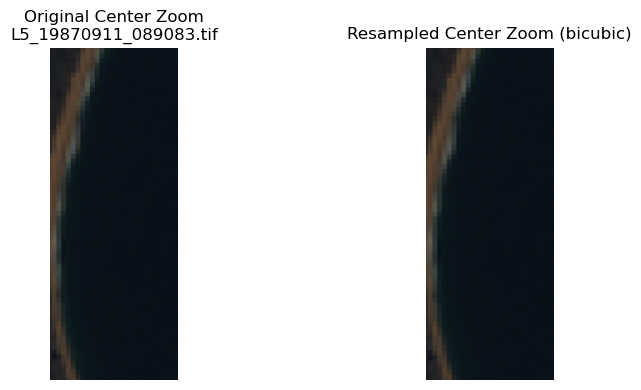

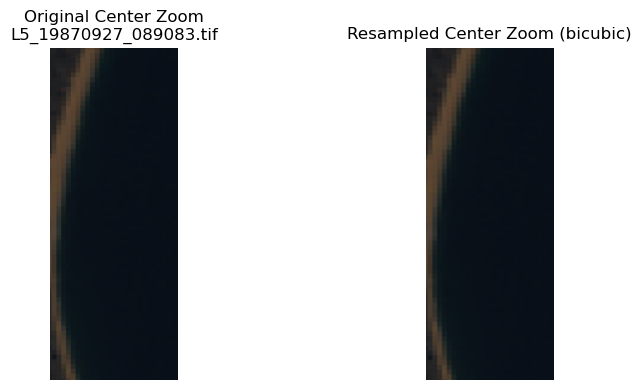

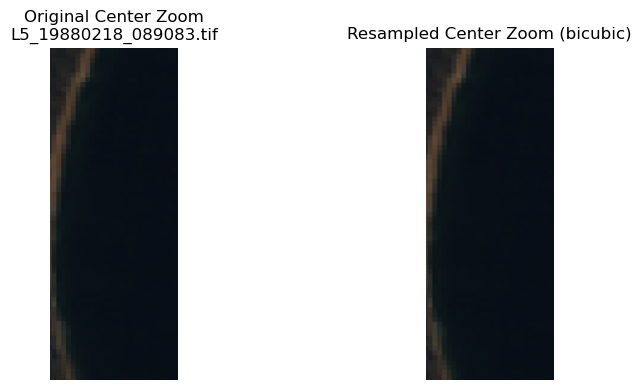

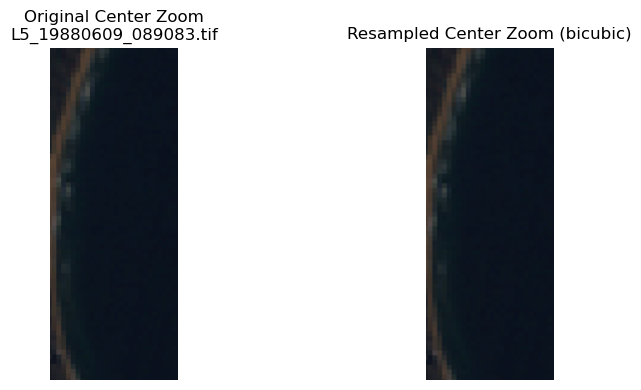

In [10]:
# Center-zoom comparison to highlight shoreline detail changes.
# This reuses tiff_files, upsample_scale, technique, resample_tiff, and to_display_array.
zoom_fraction = 0.50  # show ~12% of image width/height around center


def center_crop(arr: np.ndarray, fraction: float) -> np.ndarray:
    h, w = arr.shape[:2]
    crop_h = max(20, int(h * fraction))
    crop_w = max(20, int(w * fraction))

    cy, cx = h // 2, w // 2
    y0 = max(0, cy - crop_h // 2)
    x0 = max(0, cx - crop_w // 2)
    y1 = min(h, y0 + crop_h)
    x1 = min(w, x0 + crop_w)

    return arr[y0:y1, x0:x1]


for fp in tiff_files:
    with rasterio.open(fp) as src:
        original = src.read()  # (bands, h, w)
        height, width = src.height, src.width

    if original.shape[0] == 1:
        original_array = original[0]
    else:
        original_array = np.transpose(original, (1, 2, 0))

    desired_resolution = (height * upsample_scale, width * upsample_scale)
    upsampled_array = resample_tiff(
        tiff_path=fp,
        desired_resolution=desired_resolution,
        technique=technique,
        save_path=None,
    )

    original_display = to_display_array(original_array)
    upsampled_display = to_display_array(upsampled_array)

    original_zoom = center_crop(original_display, zoom_fraction)
    upsampled_zoom = center_crop(upsampled_display, zoom_fraction)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original_zoom, cmap='gray' if original_zoom.ndim == 2 else None)
    axes[0].set_title(f'Original Center Zoom\n{Path(fp).name}')
    axes[0].axis('off')

    axes[1].imshow(upsampled_zoom, cmap='gray' if upsampled_zoom.ndim == 2 else None)
    axes[1].set_title(f'Resampled Center Zoom ({technique})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [11]:
# Pixel-wise diagnostics: are original and resampled arrays actually identical?
# Note: for upsampling, output shape is larger, so direct equality usually is not applicable.
for fp in tiff_files:
    with rasterio.open(fp) as src:
        original = src.read()
        h, w = src.height, src.width

    if original.shape[0] == 1:
        original_array = original[0]
    else:
        original_array = np.transpose(original, (1, 2, 0))

    upsampled_array = resample_tiff(
        tiff_path=fp,
        desired_resolution=(h * upsample_scale, w * upsample_scale),
        technique=technique,
        save_path=None,
    )

    print(f'\n{Path(fp).name}')
    print(f'  original shape:  {original_array.shape}')
    print(f'  resampled shape: {upsampled_array.shape}')

    same_shape = original_array.shape == upsampled_array.shape
    if same_shape:
        print(f'  exact equal (same shape): {np.array_equal(original_array, upsampled_array)}')
    else:
        print('  exact equal (same shape): N/A (different shapes due to upsampling)')

    # For integer scale factors, compare original to every Nth resampled pixel on aligned grid.
    scale = int(upsample_scale)
    if scale > 1:
        if original_array.ndim == 2:
            sampled = upsampled_array[::scale, ::scale]
        else:
            sampled = upsampled_array[::scale, ::scale, :]

        # Clip in case dimensions differ by 1 due to rounding.
        min_h = min(original_array.shape[0], sampled.shape[0])
        min_w = min(original_array.shape[1], sampled.shape[1])
        if original_array.ndim == 2:
            a = original_array[:min_h, :min_w].astype(np.float32)
            b = sampled[:min_h, :min_w].astype(np.float32)
        else:
            min_c = min(original_array.shape[2], sampled.shape[2])
            a = original_array[:min_h, :min_w, :min_c].astype(np.float32)
            b = sampled[:min_h, :min_w, :min_c].astype(np.float32)

        diff = np.abs(a - b)
        print(f'  grid-aligned exact equal: {np.array_equal(a, b)}')
        print(f'  grid-aligned mean abs diff: {diff.mean():.6f}')
        print(f'  grid-aligned max  abs diff: {diff.max():.6f}')

        # Measure whether new interpolated pixels actually vary (i.e., not just duplicates).
        if upsampled_array.ndim == 2:
            new_pixels = upsampled_array[1::2, :]  # odd rows contain interpolated rows at scale=2
        else:
            new_pixels = upsampled_array[1::2, :, :]
        print(f'  interpolated-pixel std: {new_pixels.astype(np.float32).std():.6f}')


L5_19870522_089083.tif
  original shape:  (418, 160, 7)
  resampled shape: (836, 320, 7)
  exact equal (same shape): N/A (different shapes due to upsampling)
  grid-aligned exact equal: False
  grid-aligned mean abs diff: 0.105642
  grid-aligned max  abs diff: 166.435547
  interpolated-pixel std: 1916.685059

L5_19870911_089083.tif
  original shape:  (418, 160, 7)
  resampled shape: (836, 320, 7)
  exact equal (same shape): N/A (different shapes due to upsampling)
  grid-aligned exact equal: False
  grid-aligned mean abs diff: 0.055301
  grid-aligned max  abs diff: 108.044434
  interpolated-pixel std: 1916.144287

L5_19870927_089083.tif
  original shape:  (418, 160, 7)
  resampled shape: (836, 320, 7)
  exact equal (same shape): N/A (different shapes due to upsampling)
  grid-aligned exact equal: False
  grid-aligned mean abs diff: 0.055345
  grid-aligned max  abs diff: 124.998047
  interpolated-pixel std: 1916.188110

L5_19880218_089083.tif
  original shape:  (418, 160, 7)
  resample

Example file: L5_19870522_089083.tif
Mean abs diff (center crop, aligned grid): 0.000405
Max abs diff  (center crop, aligned grid): 0.002145


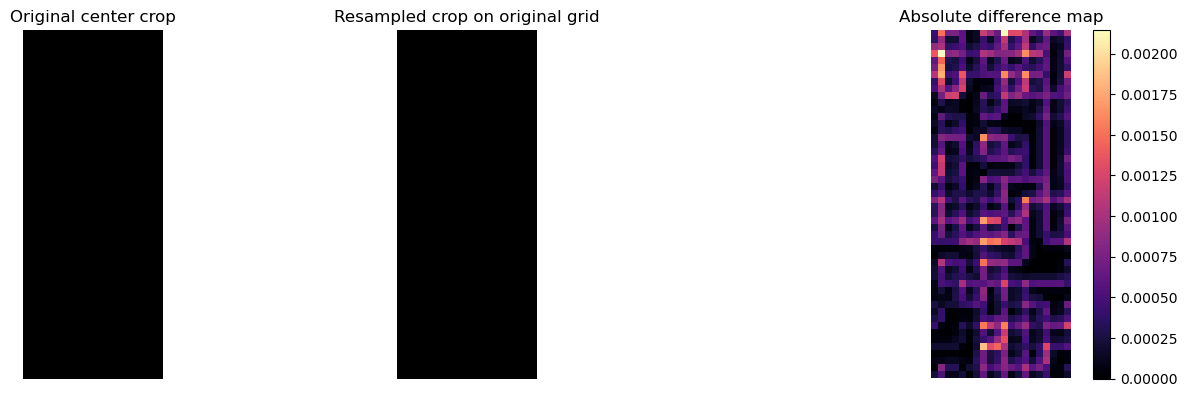

In [12]:
# Visual difference on a center crop using the same spatial footprint.
# This helps show subtle interpolation differences that may not be obvious by eye.
example_fp = tiff_files[0]

with rasterio.open(example_fp) as src:
    original = src.read()
    h, w = src.height, src.width

if original.shape[0] == 1:
    original_array = original[0]
else:
    original_array = np.transpose(original, (1, 2, 0))

resampled_array = resample_tiff(
    tiff_path=example_fp,
    desired_resolution=(h * upsample_scale, w * upsample_scale),
    technique=technique,
    save_path=None,
)

orig_disp = to_display_array(original_array)
res_disp = to_display_array(resampled_array)

# Build center crop bounds on original and map to resampled with integer scale.
fraction = 0.12
crop_h = max(20, int(orig_disp.shape[0] * fraction))
crop_w = max(20, int(orig_disp.shape[1] * fraction))
cy, cx = orig_disp.shape[0] // 2, orig_disp.shape[1] // 2

y0 = max(0, cy - crop_h // 2)
x0 = max(0, cx - crop_w // 2)
y1 = min(orig_disp.shape[0], y0 + crop_h)
x1 = min(orig_disp.shape[1], x0 + crop_w)

orig_crop = orig_disp[y0:y1, x0:x1]

scale = int(upsample_scale)
res_crop = res_disp[y0 * scale:y1 * scale, x0 * scale:x1 * scale]
res_crop_on_orig_grid = res_crop[::scale, ::scale] if orig_crop.ndim == 2 else res_crop[::scale, ::scale, :]

# Align shapes defensively.
mh = min(orig_crop.shape[0], res_crop_on_orig_grid.shape[0])
mw = min(orig_crop.shape[1], res_crop_on_orig_grid.shape[1])
if orig_crop.ndim == 2:
    a = orig_crop[:mh, :mw].astype(np.float32)
    b = res_crop_on_orig_grid[:mh, :mw].astype(np.float32)
    diff_map = np.abs(a - b)
else:
    mc = min(orig_crop.shape[2], res_crop_on_orig_grid.shape[2])
    a = orig_crop[:mh, :mw, :mc].astype(np.float32)
    b = res_crop_on_orig_grid[:mh, :mw, :mc].astype(np.float32)
    diff_map = np.abs(a - b).mean(axis=2)

print(f'Example file: {Path(example_fp).name}')
print(f'Mean abs diff (center crop, aligned grid): {diff_map.mean():.6f}')
print(f'Max abs diff  (center crop, aligned grid): {diff_map.max():.6f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(a if a.ndim == 2 else a.astype(np.uint8), cmap='gray' if a.ndim == 2 else None)
axes[0].set_title('Original center crop')
axes[0].axis('off')

axes[1].imshow(b if b.ndim == 2 else b.astype(np.uint8), cmap='gray' if b.ndim == 2 else None)
axes[1].set_title('Resampled crop on original grid')
axes[1].axis('off')

im = axes[2].imshow(diff_map, cmap='magma')
axes[2].set_title('Absolute difference map')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()